
## Final Project — Phase 3
| # | Agent | Primary Responsibility |
|---|---|---|
| 0 | **Router AI Agent** | Classifies user intent, extracts user_id, routes to specialist |
| A | **Business/Marketing Agent** | Campaign KPI analysis, customer segmentation, competitor insights |
| B | **Data Science Agent** | Workout performance analysis, fitness metric explanations |
| C | **Membership/Fraud Agent** | Suspicious login detection, account security guidance |
| D | **Order/Shipping Agent** | Real-time order tracking, delivery timelines, returns |
| E | **Product Recommendation Agent** | Workout-based product suggestions, compatibility checks |
| H | **Human-in-the-Loop** | Escalation for high-risk/compliance-sensitive scenarios |



## Section 1 — Dependencies & Setup

In [30]:
import os
import json
import warnings
import pandas as pd
import numpy as np
from typing import TypedDict, Literal, Optional, List, Dict, Any
from datetime import datetime
from IPython.display import display, Markdown, Image

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')



print('Libraries imported successfully.')

Libraries imported successfully.


In [31]:

import os
from dotenv import load_dotenv

_ = load_dotenv()
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if OPENAI_API_KEY:
    print("Key successful")
else:
    print("Key not found")
print("OPENAI_API_KEY:", OPENAI_API_KEY[:4])

Key successful
OPENAI_API_KEY: sk-p



## Section 2 — Load Training Data

In [32]:
DATA_PATH = './training_testing_data/'

campaign_df   = pd.read_csv(DATA_PATH + 'campaign_metrics_weekly.csv', parse_dates=['week_start'])
workout_df    = pd.read_csv(DATA_PATH + 'workout_sessions.csv',        parse_dates=['date'])
login_df      = pd.read_csv(DATA_PATH + 'login_events.csv',            parse_dates=['timestamp'])
orders_df     = pd.read_csv(DATA_PATH + 'orders.csv',                  parse_dates=['order_date', 'delivery_eta'])
carrier_df    = pd.read_csv(DATA_PATH + 'carrier_events.csv',          parse_dates=['event_time'])
products_df   = pd.read_csv(DATA_PATH + 'product_catalog.csv')
users_df      = pd.read_csv(DATA_PATH + 'users.csv',                   parse_dates=['join_date'])
engagement_df = pd.read_csv(DATA_PATH + 'customer_engagement.csv')
competitor_df = pd.read_csv(DATA_PATH + 'competitor_promos.csv',       parse_dates=['date'])
router_df     = pd.read_csv(DATA_PATH + 'router_intent_samples.csv')

datasets = {
    'campaign_metrics_weekly': campaign_df,
    'workout_sessions':        workout_df,
    'login_events':            login_df,
    'orders':                  orders_df,
    'carrier_events':          carrier_df,
    'product_catalog':         products_df,
    'users':                   users_df,
    'customer_engagement':     engagement_df,
    'competitor_promos':       competitor_df,
    'router_intent_samples':   router_df,
}

for name, df in datasets.items():
    print(f'  {name}.csv  →  {len(df)} rows, {df.shape[1]} columns')
print(f'\nTotal records: {sum(len(d) for d in datasets.values())}')

  campaign_metrics_weekly.csv  →  80 rows, 8 columns
  workout_sessions.csv  →  100 rows, 7 columns
  login_events.csv  →  100 rows, 6 columns
  orders.csv  →  80 rows, 8 columns
  carrier_events.csv  →  100 rows, 3 columns
  product_catalog.csv  →  60 rows, 8 columns
  users.csv  →  60 rows, 9 columns
  customer_engagement.csv  →  80 rows, 6 columns
  competitor_promos.csv  →  60 rows, 5 columns
  router_intent_samples.csv  →  80 rows, 4 columns

Total records: 800



## Section 3 — Requirement 1: Training Data & Files Inventory


In [33]:
inventory = pd.DataFrame([
    {
        'File': 'campaign_metrics_weekly.csv',
        'Agent(s)': 'Business/Marketing',
        'Used For': 'Campaign KPI Analysis — CTR, CAC, ROI computation and ranking',
        'Records': len(campaign_df),
        'Key Columns': 'week_start, campaign_id, channel, impressions, clicks, conversions, spend_usd, revenue_usd'
    },
    {
        'File': 'customer_engagement.csv',
        'Agent(s)': 'Business/Marketing',
        'Used For': 'Customer segmentation by engagement level and churn risk label',
        'Records': len(engagement_df),
        'Key Columns': 'user_id, days_since_last_workout, workouts_last_30d, avg_session_min, membership_months, churn_risk_label'
    },
    {
        'File': 'competitor_promos.csv',
        'Agent(s)': 'Business/Marketing',
        'Used For': 'Competitor promotion trend summary for strategy recommendations',
        'Records': len(competitor_df),
        'Key Columns': 'date, competitor, promo_type, discount_percent, notes'
    },
    {
        'File': 'workout_sessions.csv',
        'Agent(s)': 'Data Science',
        'Used For': 'Workout performance analysis — last N sessions per user, trend detection',
        'Records': len(workout_df),
        'Key Columns': 'user_id, date, workout_type, duration_min, avg_cadence, avg_output, avg_hr'
    },
    {
        'File': 'login_events.csv',
        'Agent(s)': 'Membership/Fraud Detection',
        'Used For': 'Suspicious login detection — failed attempts, foreign IP, anomaly scoring',
        'Records': len(login_df),
        'Key Columns': 'user_id, timestamp, device_id, ip_region, success, failed_attempts_24h'
    },
    {
        'File': 'users.csv',
        'Agent(s)': 'All Agents (shared)',
        'Used For': 'User profile lookup — tier, device, goals, consent flag for personalization',
        'Records': len(users_df),
        'Key Columns': 'user_id, role, member_tier, device_owned, preferred_workouts, goals, consent_personalization'
    },
    {
        'File': 'orders.csv',
        'Agent(s)': 'Order/Shipping',
        'Used For': 'Order status lookup — item, carrier, tracking ID, ETA',
        'Records': len(orders_df),
        'Key Columns': 'order_id, user_id, item, order_date, status, carrier, tracking_id, delivery_eta'
    },
    {
        'File': 'carrier_events.csv',
        'Agent(s)': 'Order/Shipping',
        'Used For': 'Carrier timeline construction — event sequence for delivery tracking',
        'Records': len(carrier_df),
        'Key Columns': 'tracking_id, event_time, event'
    },
    {
        'File': 'product_catalog.csv',
        'Agent(s)': 'Product Recommendation',
        'Used For': 'Product matching — filter by device compatibility, tag, rating for recommendations',
        'Records': len(products_df),
        'Key Columns': 'sku, name, category, price_usd, compatibility, rating, inventory, tags'
    },
    {
        'File': 'router_intent_samples.csv',
        'Agent(s)': 'Router',
        'Used For': 'Intent classification reference — labeled utterances for routing validation',
        'Records': len(router_df),
        'Key Columns': 'sample_id, user_text, expected_agent, slots_expected'
    },
])

pd.set_option('display.max_colwidth', 80)
display(inventory)

,File,Agent(s),Used For,Records,Key Columns
0,campaign_metrics_weekly.csv,Business/Marketing,"Campaign KPI Analysis — CTR, CAC, ROI computation and ranking",80,"week_start, campaign_id, channel, impressions, clicks, conversions, spend_us..."
1,customer_engagement.csv,Business/Marketing,Customer segmentation by engagement level and churn risk label,80,"user_id, days_since_last_workout, workouts_last_30d, avg_session_min, member..."
2,competitor_promos.csv,Business/Marketing,Competitor promotion trend summary for strategy recommendations,60,"date, competitor, promo_type, discount_percent, notes"
3,workout_sessions.csv,Data Science,"Workout performance analysis — last N sessions per user, trend detection",100,"user_id, date, workout_type, duration_min, avg_cadence, avg_output, avg_hr"
4,login_events.csv,Membership/Fraud Detection,"Suspicious login detection — failed attempts, foreign IP, anomaly scoring",100,"user_id, timestamp, device_id, ip_region, success, failed_attempts_24h"
5,users.csv,All Agents (shared),"User profile lookup — tier, device, goals, consent flag for personalization",60,"user_id, role, member_tier, device_owned, preferred_workouts, goals, consent..."
6,orders.csv,Order/Shipping,"Order status lookup — item, carrier, tracking ID, ETA",80,"order_id, user_id, item, order_date, status, carrier, tracking_id, delivery_eta"
7,carrier_events.csv,Order/Shipping,Carrier timeline construction — event sequence for delivery tracking,100,"tracking_id, event_time, event"
8,product_catalog.csv,Product Recommendation,"Product matching — filter by device compatibility, tag, rating for recommend...",60,"sku, name, category, price_usd, compatibility, rating, inventory, tags"
9,router_intent_samples.csv,Router,Intent classification reference — labeled utterances for routing validation,80,"sample_id, user_text, expected_agent, slots_expected"



## Section 4 — Requirement 2: Logical Architecture with LangGraph + Mermaid

The architecture follows the diagram in the Requirements Specification document:
- **Step 1**: User sends a message to the **Router Agent**
- **Step 2**: Router classifies intent and routes to one of 5 specialist agents (A–E)
- **Step 3**: Specialist agent fetches relevant CSV data and calls the LLM
- **Step 4**: Response is returned to the user; high-risk cases go to **Human-in-the-Loop**

In [34]:
# Mermaid architecture diagram (Requirement 2)
mermaid_diagram = """
```mermaid
graph TD
    U([User / Employee]) -->|natural language input| RT[Router AI Agent]

    RT -->|intent=marketing| MA[A: Business/Marketing Agent]
    RT -->|intent=datascience| DS[B: Data Science Agent]
    RT -->|intent=membership| MF[C: Membership/Fraud Agent]
    RT -->|intent=shipping| OS[D: Order/Shipping Agent]
    RT -->|intent=product| PR[E: Product Recommendation Agent]
    RT -->|requires_human=true| HL[Human-in-the-Loop Escalation]

    MA -->|KPI report, segmentation, competitor summary| RESP([Response to User])
    DS -->|Workout analysis, improvement plan| RESP
    MF -->|Risk assessment, security guidance| RESP
    OS -->|Order status, delivery timeline| RESP
    PR -->|Top-3 recommendations, compatibility| RESP
    HL -->|Escalation ticket, human handoff| RESP

    subgraph Data Layer
        D1[(campaign_metrics_weekly.csv)]
        D2[(workout_sessions.csv)]
        D3[(login_events.csv)]
        D4[(orders.csv + carrier_events.csv)]
        D5[(product_catalog.csv)]
        D6[(users.csv)]
    end

    MA -.->|reads| D1
    DS -.->|reads| D2
    MF -.->|reads| D3
    OS -.->|reads| D4
    PR -.->|reads| D5
    RT -.->|reads| D6

    style RT fill:#6c3483,color:#fff
    style MA fill:#1a5276,color:#fff
    style DS fill:#1e8449,color:#fff
    style MF fill:#922b21,color:#fff
    style OS fill:#784212,color:#fff
    style PR fill:#154360,color:#fff
    style HL fill:#616a6b,color:#fff
```
"""
display(Markdown(mermaid_diagram))


```mermaid
graph TD
    U([User / Employee]) -->|natural language input| RT[Router AI Agent]

    RT -->|intent=marketing| MA[A: Business/Marketing Agent]
    RT -->|intent=datascience| DS[B: Data Science Agent]
    RT -->|intent=membership| MF[C: Membership/Fraud Agent]
    RT -->|intent=shipping| OS[D: Order/Shipping Agent]
    RT -->|intent=product| PR[E: Product Recommendation Agent]
    RT -->|requires_human=true| HL[Human-in-the-Loop Escalation]

    MA -->|KPI report, segmentation, competitor summary| RESP([Response to User])
    DS -->|Workout analysis, improvement plan| RESP
    MF -->|Risk assessment, security guidance| RESP
    OS -->|Order status, delivery timeline| RESP
    PR -->|Top-3 recommendations, compatibility| RESP
    HL -->|Escalation ticket, human handoff| RESP

    subgraph Data Layer
        D1[(campaign_metrics_weekly.csv)]
        D2[(workout_sessions.csv)]
        D3[(login_events.csv)]
        D4[(orders.csv + carrier_events.csv)]
        D5[(product_catalog.csv)]
        D6[(users.csv)]
    end

    MA -.->|reads| D1
    DS -.->|reads| D2
    MF -.->|reads| D3
    OS -.->|reads| D4
    PR -.->|reads| D5
    RT -.->|reads| D6

    style RT fill:#6c3483,color:#fff
    style MA fill:#1a5276,color:#fff
    style DS fill:#1e8449,color:#fff
    style MF fill:#922b21,color:#fff
    style OS fill:#784212,color:#fff
    style PR fill:#154360,color:#fff
    style HL fill:#616a6b,color:#fff
```



## Section 5 — Requirement 3: Instrumented Agent Code Templates

This section defines:
1. The shared **PelotonState** TypedDict
2. **Data-fetcher tool functions** (one per agent)
3. **LLM node functions** for all 5 agents + router + human escalation
4. The compiled **LangGraph StateGraph**

In [35]:
# ─────────────────────────────────────────────────────────────
# 5.1  Shared State Definition
# ─────────────────────────────────────────────────────────────
class PelotonState(TypedDict):
    """Typed state object shared across every LangGraph node."""
    user_input:           str             # Raw natural-language message from user
    user_id:              Optional[str]   # Extracted member/employee ID (e.g. 'U001')
    agent:                str             # Name of the routed specialist agent
    data_context:         str             # CSV-derived context string passed to LLM
    agent_response:       str             # Final formatted answer returned to user
    requires_human:       bool            # True → escalate to human support
    risk_level:           str             # 'low' | 'medium' | 'high'
    conversation_history: List[Dict]      # Multi-turn chat log

print('PelotonState defined.')

PelotonState defined.


In [36]:
# ─────────────────────────────────────────────────────────────
# 5.2  LLM Initialization
# ─────────────────────────────────────────────────────────────
llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0.3,
    openai_api_key=OPENAI_API_KEY,
)

# Separate instance forcing JSON output for the router
llm_json = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0.0,
    model_kwargs={'response_format': {'type': 'json_object'}},
    openai_api_key=OPENAI_API_KEY,
)

print('LLM instances initialized (model=gpt-4o-mini).')

LLM instances initialized (model=gpt-4o-mini).


In [37]:
# ─────────────────────────────────────────────────────────────
# 5.3  Data-Fetcher Tool Functions  (pandas-based, no external API)
# ─────────────────────────────────────────────────────────────

# ── Tool A: Campaign KPI Computation ─────────────────────────
def fetch_campaign_kpis() -> str:
    """Compute CTR, CAC, ROI per campaign and return a formatted summary string."""
    df = campaign_df.copy()
    df['CTR'] = (df['clicks'] / df['impressions'] * 100).round(2)
    df['CAC'] = (df['spend_usd'] / df['conversions'].replace(0, np.nan)).round(2)
    df['ROI'] = ((df['revenue_usd'] - df['spend_usd']) / df['spend_usd'] * 100).round(1)

    agg = (
        df.groupby('campaign_id')
          .agg(
              channel=('channel', 'first'),
              avg_CTR=('CTR', 'mean'),
              avg_CAC=('CAC', 'mean'),
              avg_ROI=('ROI', 'mean'),
              total_spend=('spend_usd', 'sum'),
              total_revenue=('revenue_usd', 'sum')
          )
          .reset_index()
          .sort_values('avg_ROI', ascending=False)
    )
    agg[['avg_CTR','avg_CAC','avg_ROI']] = agg[['avg_CTR','avg_CAC','avg_ROI']].round(2)

    total_spend   = df['spend_usd'].sum()
    total_revenue = df['revenue_usd'].sum()
    overall_roi   = (total_revenue - total_spend) / total_spend * 100

    top3_str    = agg.head(3)[['campaign_id','channel','avg_CTR','avg_CAC','avg_ROI']].to_string(index=False)
    bottom3_str = agg.tail(3)[['campaign_id','channel','avg_CTR','avg_CAC','avg_ROI']].to_string(index=False)

    return (
        f'PORTFOLIO SUMMARY\n'
        f'  Total Spend:   ${total_spend:,.2f}\n'
        f'  Total Revenue: ${total_revenue:,.2f}\n'
        f'  Overall ROI:   {overall_roi:.1f}%\n\n'
        f'TOP 3 CAMPAIGNS (highest ROI):\n{top3_str}\n\n'
        f'BOTTOM 3 CAMPAIGNS (lowest ROI):\n{bottom3_str}'
    )


# ── Tool B: Workout History Retrieval ────────────────────────
def fetch_workout_history(user_id: str, n: int = 10) -> str:
    """Return last N workout sessions for a user with aggregate statistics."""
    df = workout_df[workout_df['user_id'] == user_id].sort_values('date', ascending=False).head(n)
    if df.empty:
        return f'No workout data found for user {user_id}.'

    summary = {
        'sessions_retrieved': len(df),
        'workout_types':      df['workout_type'].value_counts().to_dict(),
        'avg_duration_min':   round(df['duration_min'].mean(), 1),
        'avg_cadence':        round(df['avg_cadence'].mean(), 1) if df['avg_cadence'].notna().any() else 'N/A',
        'avg_output':         round(df['avg_output'].mean(), 1)  if df['avg_output'].notna().any()  else 'N/A',
        'avg_heart_rate':     round(df['avg_hr'].mean(), 1)      if df['avg_hr'].notna().any()      else 'N/A',
    }
    table = df[['date','workout_type','duration_min','avg_cadence','avg_output','avg_hr']].to_string(index=False)
    return f'Last {len(df)} sessions for {user_id}:\n{table}\n\nAggregate Stats:\n{json.dumps(summary, indent=2)}'


# ── Tool C: Login Risk Assessment ────────────────────────────
def fetch_login_risk(user_id: str) -> str:
    """Analyze login events for anomalies and return a risk report string."""
    df = login_df[login_df['user_id'] == user_id].sort_values('timestamp', ascending=False)
    if df.empty:
        return f'No login records found for user {user_id}.'

    failed_logins    = df[df['success'] == False]
    foreign_logins   = df[~df['ip_region'].isin(['US', 'CA', 'UK'])]
    max_failed_24h   = int(df['failed_attempts_24h'].max())
    unique_devices   = df['device_id'].nunique()

    risk_score, flags = 0, []
    if len(failed_logins) > 0:
        risk_score += 30
        flags.append(f'{len(failed_logins)} failed login attempt(s) on record')
    if len(foreign_logins) > 0:
        risk_score += 40
        flags.append(f'Login(s) from unexpected region(s): {foreign_logins["ip_region"].unique().tolist()}')
    if max_failed_24h >= 5:
        risk_score += 30
        flags.append(f'High failed-attempt count in 24 h window: {max_failed_24h}')
    if unique_devices > 3:
        risk_score += 10
        flags.append(f'Multiple devices used: {unique_devices}')

    risk_level = 'HIGH' if risk_score >= 60 else 'MEDIUM' if risk_score >= 30 else 'LOW'
    recent = df.head(5)[['timestamp','device_id','ip_region','success','failed_attempts_24h']].to_string(index=False)

    return (
        f'RISK LEVEL: {risk_level}  (score={risk_score}/100)\n'
        f'FLAGS: {chr(10).join("  - " + f for f in flags) if flags else "  None detected"}\n\n'
        f'Recent Login Events:\n{recent}'
    )


# ── Tool D: Order Status + Carrier Timeline ───────────────────
def fetch_order_status(user_id: str = None, order_id: str = None) -> str:
    """Fetch latest order for a user and build carrier event timeline."""
    if order_id:
        orders = orders_df[orders_df['order_id'] == order_id]
    elif user_id:
        orders = orders_df[orders_df['user_id'] == user_id].sort_values('order_date', ascending=False)
    else:
        return 'Provide an order_id or user_id.'

    if orders.empty:
        return 'No orders found.'

    row = orders.iloc[0]
    tracking_id = row['tracking_id']
    events = carrier_df[carrier_df['tracking_id'] == tracking_id].sort_values('event_time')
    events_str = events[['event_time','event']].to_string(index=False) if not events.empty else 'No carrier events recorded yet.'

    order_date_str = row['order_date'].strftime('%Y-%m-%d') if pd.notna(row['order_date']) else 'N/A'
    eta_str        = row['delivery_eta'].strftime('%Y-%m-%d') if pd.notna(row['delivery_eta']) else 'N/A'

    return (
        f'ORDER ID:     {row["order_id"]}\n'
        f'ITEM:         {row["item"]}\n'
        f'STATUS:       {row["status"]}\n'
        f'CARRIER:      {row["carrier"]}  |  Tracking: {tracking_id}\n'
        f'ORDER DATE:   {order_date_str}\n'
        f'DELIVERY ETA: {eta_str}\n\n'
        f'Carrier Event Timeline:\n{events_str}'
    )


# ── Tool E: Product Recommendations ──────────────────────────
def fetch_product_recommendations(user_id: str, top_n: int = 3) -> str:
    """Recommend top-N products based on user workout history and device compatibility."""
    user_row = users_df[users_df['user_id'] == user_id]
    if user_row.empty:
        return f'User {user_id} not found.'

    user = user_row.iloc[0]
    device = user['device_owned']

    workouts = workout_df[workout_df['user_id'] == user_id]['workout_type'].value_counts()
    top_workout = workouts.index[0] if not workouts.empty else 'cycling'

    tag_map = {
        'cycling':   'cycling',  'running':  'running',   'strength': 'strength',
        'yoga':      'yoga',     'walking':  'running',   'row':      'rowing',
        'bootcamp':  'strength', 'meditation': 'mindfulness'
    }
    target_tag = tag_map.get(top_workout, 'cycling')

    # Filter: device-compatible or 'Any'
    compatible = products_df[
        products_df['compatibility'].str.contains(device.split('+')[0], na=False, regex=False) |
        products_df['compatibility'].str.contains('Any', na=False)
    ]
    # Soft tag filter
    tagged = compatible[compatible['tags'].str.contains(target_tag, case=False, na=False)]
    pool   = tagged if len(tagged) >= top_n else compatible
    top    = pool.sort_values('rating', ascending=False).head(top_n)

    recs = top[['sku','name','category','price_usd','rating','compatibility']].to_string(index=False)

    return (
        f'USER PROFILE: {user_id} | Device: {device} | Top workout: {top_workout}\n'
        f'Goals: {user.get("goals", "N/A")}  |  Preferred workouts: {user.get("preferred_workouts", "N/A")}\n\n'
        f'Top {len(top)} Recommended Products:\n{recs}'
    )


print('All 5 data-fetcher tool functions defined.')

All 5 data-fetcher tool functions defined.


In [38]:
# ─────────────────────────────────────────────────────────────
# 5.3-EXT  Extended Data-Fetcher Tools
# These support the additional user stories (A2, A3, B2, D3)
# without modifying the core logic in 5.3.
# ─────────────────────────────────────────────────────────────

# ── Tool A2: Customer Segmentation by Engagement & Churn Risk ──
def fetch_customer_segments() -> str:
    """Segment customers by engagement and churn risk for sales follow-up."""
    df = engagement_df.copy()
    by_risk = df.groupby('churn_risk_label').agg(
        members=('user_id', 'count'),
        avg_days_inactive=('days_since_last_workout', 'mean'),
        avg_workouts_30d=('workouts_last_30d', 'mean'),
        avg_session_min=('avg_session_min', 'mean'),
        avg_membership_months=('membership_months', 'mean')
    ).round(1).reset_index()

    high_risk = df[df['churn_risk_label'].str.lower() == 'high'].head(10)
    high_risk_str = high_risk[['user_id','days_since_last_workout','workouts_last_30d','membership_months']].to_string(index=False) if not high_risk.empty else 'No high-risk members detected.'

    return (
        f'CUSTOMER SEGMENTATION BY CHURN RISK\n'
        f'Total members analyzed: {len(df)}\n\n'
        f'{by_risk.to_string(index=False)}\n\n'
        f'TOP 10 HIGH-RISK MEMBERS (priority outreach list):\n{high_risk_str}'
    )


# ── Tool A3: Competitor Promotion Trends ────────────────────
def fetch_competitor_trends() -> str:
    """Summarize competitor promotions for brand strategy."""
    df = competitor_df.copy()
    by_competitor = df.groupby('competitor').agg(
        promo_count=('promo_type', 'count'),
        avg_discount_pct=('discount_percent', 'mean'),
        max_discount_pct=('discount_percent', 'max')
    ).round(1).reset_index().sort_values('avg_discount_pct', ascending=False)

    by_promo_type = df.groupby('promo_type').agg(
        count=('competitor', 'count'),
        avg_discount_pct=('discount_percent', 'mean')
    ).round(1).reset_index().sort_values('count', ascending=False)

    recent = df.sort_values('date', ascending=False).head(15)
    recent_str = recent[['date','competitor','promo_type','discount_percent','notes']].to_string(index=False)

    return (
        f'COMPETITOR ACTIVITY OVERVIEW\n'
        f'Total promotions tracked: {len(df)}\n\n'
        f'BY COMPETITOR:\n{by_competitor.to_string(index=False)}\n\n'
        f'BY PROMO TYPE:\n{by_promo_type.to_string(index=False)}\n\n'
        f'RECENT 15 PROMOTIONS:\n{recent_str}'
    )


# ── Tool B2: Aggregate Engagement & Churn Trends (analyst view) ──
def fetch_engagement_trends() -> str:
    """Aggregate churn and engagement insights for internal analyst reporting."""
    df = engagement_df.copy()
    by_risk = df.groupby('churn_risk_label').agg(
        members=('user_id', 'count'),
        avg_days_inactive=('days_since_last_workout', 'mean'),
        avg_workouts_30d=('workouts_last_30d', 'mean'),
        avg_session_min=('avg_session_min', 'mean'),
        avg_tenure_months=('membership_months', 'mean')
    ).round(1).reset_index()

    high = df[df['churn_risk_label'].str.lower() == 'high']
    low  = df[df['churn_risk_label'].str.lower() == 'low']

    high_avg_inactive = high['days_since_last_workout'].mean() if not high.empty else 0
    low_avg_inactive  = low['days_since_last_workout'].mean()  if not low.empty  else 0
    high_avg_workouts = high['workouts_last_30d'].mean()       if not high.empty else 0
    low_avg_workouts  = low['workouts_last_30d'].mean()        if not low.empty  else 0

    return (
        f'ENGAGEMENT & CHURN TRENDS (population level)\n'
        f'Total members analyzed: {len(df)}\n\n'
        f'SEGMENT BREAKDOWN:\n{by_risk.to_string(index=False)}\n\n'
        f'KEY OBSERVATIONS:\n'
        f'  - High-risk avg days inactive: {high_avg_inactive:.0f} vs Low-risk: {low_avg_inactive:.0f}\n'
        f'  - High-risk avg workouts/30d:  {high_avg_workouts:.1f} vs Low-risk: {low_avg_workouts:.1f}\n'
        f'  - Inactivity gap suggests workout frequency is a leading churn indicator.'
    )


# ── Tool D3: Delayed Shipments Summary ──────────────────────
def fetch_delayed_shipments() -> str:
    """Summarize delayed/in-transit orders for fulfillment team."""
    delayed = orders_df[orders_df['status'].str.lower().isin(['delayed', 'processing', 'shipped'])].copy()
    if delayed.empty:
        return 'No delayed or in-transit shipments currently on record.'

    by_carrier = delayed.groupby('carrier').size().reset_index(name='count').sort_values('count', ascending=False)
    by_status  = delayed.groupby('status').size().reset_index(name='count').sort_values('count', ascending=False)

    sample = delayed.sort_values('order_date').head(10)
    sample_str = sample[['order_id','user_id','item','status','carrier','order_date','delivery_eta']].to_string(index=False)

    return (
        f'DELAYED / IN-TRANSIT SHIPMENT SUMMARY\n'
        f'Total flagged orders: {len(delayed)}\n\n'
        f'BY CARRIER:\n{by_carrier.to_string(index=False)}\n\n'
        f'BY STATUS:\n{by_status.to_string(index=False)}\n\n'
        f'OLDEST 10 OUTSTANDING ORDERS (priority resolution):\n{sample_str}'
    )


print('Extended data tools defined: A2 segments, A3 competitors, B2 engagement trends, D3 delayed shipments.')

Extended data tools defined: A2 segments, A3 competitors, B2 engagement trends, D3 delayed shipments.


In [39]:
# ─────────────────────────────────────────────────────────────
# 5.4  Router Node
# ─────────────────────────────────────────────────────────────
ROUTER_SYSTEM = """You are the Peloton Router AI Agent.
Read the user's message and return ONLY a valid JSON object routing them to the correct specialist.

Available agents:
  "marketing"   → campaigns, ROI, customer segmentation, competitor analysis, promotions
  "datascience"  → workout performance, fitness metrics, churn trends, analytics insights
  "membership"   → suspicious login, account security, password reset, membership tiers, fraud
  "shipping"     → order tracking, delivery, returns, exchanges, missing orders
  "product"      → product recommendations, compatibility, bundling, pricing

Return exactly this JSON structure (no markdown, no explanation):
{
  "agent": "<agent name>",
  "user_id": "<extracted ID like U001, or null>",
  "requires_human": <true if confirmed fraud / financial dispute / identity crisis, else false>,
  "risk_level": "<low | medium | high>"
}"""

def router_node(state: PelotonState) -> PelotonState:
    """Router: classify intent and set routing fields on state."""
    messages = [
        SystemMessage(content=ROUTER_SYSTEM),
        HumanMessage(content=state['user_input'])
    ]
    resp = llm_json.invoke(messages)
    routing = json.loads(resp.content)
    return {
        **state,
        'agent':          routing.get('agent', 'membership'),
        'user_id':        routing.get('user_id') or state.get('user_id'),
        'requires_human': routing.get('requires_human', False),
        'risk_level':     routing.get('risk_level', 'low'),
    }

def route_decision(state: PelotonState) -> str:
    """Conditional edge: return node name based on state."""
    if state.get('requires_human'):
        return 'human'
    return state.get('agent', 'membership')

print('Router node defined.')

Router node defined.


In [40]:
# ─────────────────────────────────────────────────────────────
# 5.5  Agent A — Business/Marketing Node (now supports US-A1, A2, A3)
# Branches on user query to pull the right data context.
# Core LLM logic and system prompt unchanged.
# ─────────────────────────────────────────────────────────────
MARKETING_SYSTEM = """You are the Peloton Business/Marketing AI Agent.
You have access to real campaign performance, customer engagement, and competitor data.

Depending on the data context provided, you may be asked to:
(a) Analyze campaign KPIs (CTR, CAC, ROI) and recommend budget reallocation.
(b) Segment customers by churn risk and recommend personalized follow-up strategies.
(c) Summarize competitor promotions and suggest pricing/campaign adjustments.

When responding:
1. Start with a brief executive summary (2-3 sentences)
2. Use the specific numbers provided in the data context
3. Give 3 actionable recommendations tied to the data

Guardrails:
- Only report numbers from the provided data — do not invent metrics
- Label any missing data clearly
- This view is for authorized marketing employees only"""

def marketing_agent(state: PelotonState) -> PelotonState:
    """Business/Marketing Agent node — KPI / segmentation / competitor analysis."""
    query = state['user_input'].lower()

    # Branch: pick the right data tool based on intent keywords
    if any(k in query for k in ['segment', 'churn', 'follow up', 'follow-up', 'outreach', 'personalize', 'engagement']):
        data_ctx = fetch_customer_segments()
        sub_intent = 'segmentation'
    elif any(k in query for k in ['competitor', 'rival', 'market trend', 'pricing', 'promo']):
        data_ctx = fetch_competitor_trends()
        sub_intent = 'competitor'
    else:
        data_ctx = fetch_campaign_kpis()
        sub_intent = 'kpi'

    messages = [
        SystemMessage(content=MARKETING_SYSTEM),
        HumanMessage(
            content=f'User query: {state["user_input"]}\n\n'
                    f'Sub-intent detected: {sub_intent}\n\n'
                    f'--- Marketing Data Context ---\n{data_ctx}\n---\n\n'
                    f'Analyze this data and provide actionable recommendations.'
        )
    ]
    response = llm.invoke(messages)
    return {**state, 'data_context': data_ctx, 'agent_response': response.content}

print('Business/Marketing Agent node defined (supports US-A1, A2, A3).')

Business/Marketing Agent node defined (supports US-A1, A2, A3).


In [41]:
# ─────────────────────────────────────────────────────────────
# 5.6  Agent B — Data Science Node (now supports US-B1, B2, B3)
# B1: Last 10 workouts + improvements (per-user)
# B2: Aggregate churn/engagement trend report (population)
# B3: Plain-language explanation of personal stats (per-user, prompt-driven)
# ─────────────────────────────────────────────────────────────
DATA_SCIENCE_SYSTEM = """You are the Peloton Data Science AI Agent.
You analyze fitness and engagement data to provide insights at either the individual or population level.

Depending on the data context provided, you may be asked to:
(a) Review a member's workout history and suggest measurable improvements (3-5 targets).
(b) Explain population-level churn/engagement trends for an internal analyst.
(c) Explain a member's performance stats in simple, plain language (no jargon).

When responding:
- For individual reviews: summarize patterns, highlight strengths, give 3-5 measurable improvement targets, suggest a weekly goal.
- For trend reports: explain what's driving the numbers and give actionable insights.
- For plain-language explanations: avoid jargon; use everyday analogies.

Guardrails:
- Use encouraging, supportive language — avoid body-shaming or negative framing
- Do NOT make medical claims or diagnose conditions
- End every response with: 'These suggestions are for fitness guidance only and are not medical advice.'"""

def datascience_agent(state: PelotonState) -> PelotonState:
    """Data Science Agent node — handles B1 (individual), B2 (aggregate), B3 (plain-language)."""
    query = state['user_input'].lower()
    user_id = state.get('user_id') or 'U053'

    # Branch: aggregate trend report (B2) vs personal analysis (B1, B3)
    if any(k in query for k in ['churn trend', 'engagement trend', 'population', 'analyst', 'leadership report', 'overall trend', 'company-wide', 'company wide']):
        data_ctx = fetch_engagement_trends()
        sub_intent = 'aggregate_trends'
    else:
        data_ctx = fetch_workout_history(user_id, n=10)
        # B3 detection: user wants simple/plain language explanation
        if any(k in query for k in ['simple language', 'plain language', 'explain my', 'what does', 'understand']):
            sub_intent = 'plain_language'
        else:
            sub_intent = 'individual_analysis'

    messages = [
        SystemMessage(content=DATA_SCIENCE_SYSTEM),
        HumanMessage(
            content=f'User query: {state["user_input"]}\n\n'
                    f'Sub-intent detected: {sub_intent}\n\n'
                    f'--- Data Context ---\n{data_ctx}\n---\n\n'
                    f'Provide an appropriate response based on the sub-intent.'
        )
    ]
    response = llm.invoke(messages)
    return {**state, 'data_context': data_ctx, 'agent_response': response.content}

print('Data Science Agent node defined (supports US-B1, B2, B3).')

Data Science Agent node defined (supports US-B1, B2, B3).


In [42]:
# ─────────────────────────────────────────────────────────────
# 5.7  Agent C — Membership/Fraud Detection Node
# Selected User Story: Detect suspicious login activity + guide account security
# ─────────────────────────────────────────────────────────────
MEMBERSHIP_SYSTEM = """You are the Peloton Membership & Fraud Detection AI Agent.
You help members identify suspicious account activity and secure their accounts.

When a security concern is raised:
1. State the detected risk level clearly (LOW / MEDIUM / HIGH)
2. Explain which specific anomalies were found
3. Provide numbered step-by-step security actions the member should take NOW
4. If risk is HIGH, always end with an escalation recommendation to human support

Guardrails:
- NEVER ask for passwords, full card numbers, or SSN
- Be calm and reassuring — members may be distressed
- If risk is LOW, still validate the concern and provide proactive advice
- Always protect PII — do not echo back sensitive data in your response"""

def membership_agent(state: PelotonState) -> PelotonState:
    """Membership/Fraud Agent node — Suspicious login detection & security guidance."""
    user_id  = state.get('user_id') or 'U028'
    data_ctx = fetch_login_risk(user_id)

    messages = [
        SystemMessage(content=MEMBERSHIP_SYSTEM),
        HumanMessage(
            content=f'User query: {state["user_input"]}\n\n'
                    f'--- Login Security Analysis for {user_id} ---\n{data_ctx}\n---\n\n'
                    f'Provide a risk assessment and step-by-step account security guidance.'
        )
    ]
    response = llm.invoke(messages)
    return {**state, 'data_context': data_ctx, 'agent_response': response.content}

print('Membership/Fraud Agent node defined.')

Membership/Fraud Agent node defined.


In [43]:
# ─────────────────────────────────────────────────────────────
# 5.8  Agent D — Order/Shipping Node (now supports US-D1, D2, D3)
# D1: Real-time order tracking (per-user)
# D2: Returns/exchanges step-by-step guidance (uses order context + policy prompt)
# D3: Delayed shipments summary by carrier (employee view)
# ─────────────────────────────────────────────────────────────
SHIPPING_SYSTEM = """You are the Peloton Order & Shipping AI Agent.
You provide order tracking, returns guidance, and fulfillment summaries.

Depending on the context provided, you may handle:
(a) Real-time order tracking with carrier timeline.
(b) Step-by-step returns/exchanges guidance (within 30-day policy window from order_date).
(c) Summary of delayed shipments grouped by carrier/region for fulfillment employees.

When responding:
1. For tracking: state status in plain language, show timeline chronologically, give the ETA.
2. For returns: walk the customer through numbered steps; verify the 30-day window.
3. For fulfillment summaries: lead with the totals, then show breakdowns and the priority list.

Guardrails:
- Only show the requesting user's own order — never expose other customers' data
- For returns: check the 30-day window from order_date before confirming eligibility
- For damage/disputes: always escalate to human support — do not promise refunds autonomously"""

def shipping_agent(state: PelotonState) -> PelotonState:
    """Order/Shipping Agent node — tracking / returns / delayed shipment summary."""
    query = state['user_input'].lower()
    user_id = state.get('user_id') or 'U014'

    # Branch: employee-facing delayed summary vs customer-facing tracking/returns
    if any(k in query for k in ['delayed shipment', 'delayed orders', 'delays', 'fulfillment', 'all orders', 'by region', 'by carrier']):
        data_ctx = fetch_delayed_shipments()
        sub_intent = 'delayed_summary'
    else:
        data_ctx = fetch_order_status(user_id=user_id)
        if any(k in query for k in ['return', 'exchange', 'refund', 'send back']):
            sub_intent = 'returns'
        else:
            sub_intent = 'tracking'

    messages = [
        SystemMessage(content=SHIPPING_SYSTEM),
        HumanMessage(
            content=f'User query: {state["user_input"]}\n\n'
                    f'Sub-intent detected: {sub_intent}\n\n'
                    f'--- Order/Shipping Data ---\n{data_ctx}\n---\n\n'
                    f'Provide a clear, helpful response based on the sub-intent.'
        )
    ]
    response = llm.invoke(messages)
    return {**state, 'data_context': data_ctx, 'agent_response': response.content}

print('Order/Shipping Agent node defined (supports US-D1, D2, D3).')

Order/Shipping Agent node defined (supports US-D1, D2, D3).


In [44]:
# ─────────────────────────────────────────────────────────────
# 5.9  Agent E — Product Recommendation Node
# Selected User Story: Recommend products based on workout history
# ─────────────────────────────────────────────────────────────
PRODUCT_SYSTEM = """You are the Peloton Product Recommendation AI Agent.
You suggest personalized products based on the member's workout history, device, and goals.

When making recommendations:
1. Acknowledge the member's primary workout type and device
2. Present exactly 3 ranked product recommendations
3. For each product: name, price, star rating, WHY it fits this member, compatibility note
4. End with a brief note on how these products support their stated fitness goals

Guardrails:
- Only recommend products that appear in the provided catalog — do not invent items
- Avoid aggressive upselling language; be genuinely helpful
- Always include the compatibility note so the member knows the product works with their device"""

def product_agent(state: PelotonState) -> PelotonState:
    """Product Recommendation Agent node — Workout-based recommendations."""
    user_id  = state.get('user_id') or 'U001'
    data_ctx = fetch_product_recommendations(user_id, top_n=3)

    messages = [
        SystemMessage(content=PRODUCT_SYSTEM),
        HumanMessage(
            content=f'User query: {state["user_input"]}\n\n'
                    f'--- Personalized Product Data for {user_id} ---\n{data_ctx}\n---\n\n'
                    f'Generate a friendly, personalized product recommendation response.'
        )
    ]
    response = llm.invoke(messages)
    return {**state, 'data_context': data_ctx, 'agent_response': response.content}

print('Product Recommendation Agent node defined.')

Product Recommendation Agent node defined.


In [45]:
# ─────────────────────────────────────────────────────────────
# 5.10  Human-in-the-Loop Escalation Node
# ─────────────────────────────────────────────────────────────
def human_escalation_node(state: PelotonState) -> PelotonState:
    """Generate an escalation ticket and safety guidance for high-risk cases."""
    ticket_id = f'ESC-{datetime.now().strftime("%Y%m%d-%H%M%S")}'
    response = (
        f'**ESCALATION INITIATED**\n\n'
        f'Your case requires immediate attention from our security team.\n'
        f'**Ticket ID:** {ticket_id}\n'
        f'**Risk Level:** {state.get("risk_level", "HIGH").upper()}\n\n'
        f'**Immediate steps while you wait:**\n'
        f'1. Sign out of all devices at peloton.com/account/security\n'
        f'2. Change your password from a trusted device\n'
        f'3. Enable two-factor authentication if not already active\n'
        f'4. Contact us directly at security@peloton.com for urgent cases\n\n'
        f'A Peloton specialist will contact you within 2 hours. '
        f'Your account security is our top priority.'
    )
    return {**state, 'agent_response': response}

print('Human escalation node defined.')

Human escalation node defined.


LangGraph workflow compiled successfully.

LangGraph-generated Mermaid diagram:


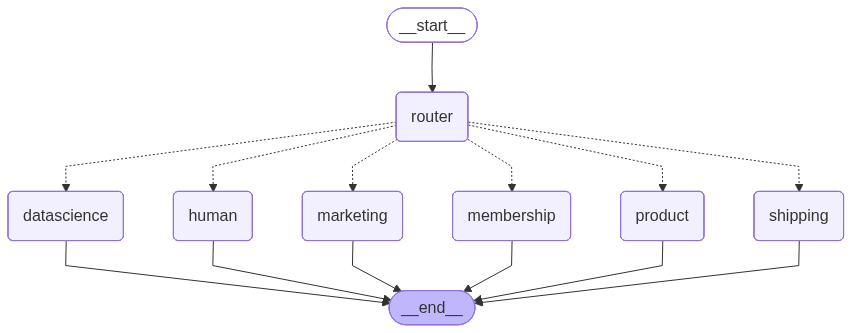

In [46]:
# ─────────────────────────────────────────────────────────────
# 5.11  Compile the LangGraph Workflow
# ─────────────────────────────────────────────────────────────
workflow = StateGraph(PelotonState)

# Register nodes
workflow.add_node('router',      router_node)
workflow.add_node('marketing',   marketing_agent)
workflow.add_node('datascience', datascience_agent)
workflow.add_node('membership',  membership_agent)
workflow.add_node('shipping',    shipping_agent)
workflow.add_node('product',     product_agent)
workflow.add_node('human',       human_escalation_node)

# Entry point
workflow.set_entry_point('router')

# Conditional routing from router → specialist agents
workflow.add_conditional_edges(
    'router',
    route_decision,
    {
        'marketing':   'marketing',
        'datascience': 'datascience',
        'membership':  'membership',
        'shipping':    'shipping',
        'product':     'product',
        'human':       'human',
    }
)

# Each specialist leads to END
for node_name in ['marketing', 'datascience', 'membership', 'shipping', 'product', 'human']:
    workflow.add_edge(node_name, END)

# Compile
app = workflow.compile()
print('LangGraph workflow compiled successfully.')

# ── Render LangGraph Mermaid diagram ─────────────────────────
print('\nLangGraph-generated Mermaid diagram:')
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    mermaid_text = app.get_graph().draw_mermaid()
    display(Markdown(f'```\n{mermaid_text}\n```'))


## Section 6 — Requirement 4: Working Prototypes

One user story is implemented as a working prototype for each of the five agents.

| Agent | Selected User Story |
|---|---|
| Business/Marketing | US-A1: Analyze weekly campaign performance (CTR, CAC, ROI) |
| Data Science | US-B1: Analyze last 10 workouts + suggest measurable improvements |
| Membership/Fraud | US-C1: Detect suspicious login activity + guide account security |
| Order/Shipping | US-D1: Provide real-time order tracking with delivery timeline |
| Product Recommendation | US-E1: Recommend products based on workout history |


In [47]:
def run_agent(user_input: str, user_id: str = None, label: str = '') -> dict:
    """Helper: build initial state, invoke the graph, print results."""
    init_state = {
        'user_input':           user_input,
        'user_id':              user_id,
        'agent':                '',
        'data_context':         '',
        'agent_response':       '',
        'requires_human':       False,
        'risk_level':           'low',
        'conversation_history': []
    }
    result = app.invoke(init_state)
    if label:
        display(Markdown(f'### {label}'))
    display(Markdown(f'**Routed to:** `{result["agent"].upper()}` agent  |  Risk: `{result["risk_level"]}`  |  Human needed: `{result["requires_human"]}`'))
    display(Markdown('**Agent Response:**'))
    display(Markdown(result['agent_response']))
    print('─' * 70)
    return result

print('Helper function defined.')

Helper function defined.


### Prototype A — Business/Marketing Agent
**User Story US-A1:** *As a marketing specialist, I want the AI agent to analyze weekly campaign performance (CTR, CAC, ROI) so that I can identify high-performing campaigns and optimize ad spending.*

In [48]:
# Preview the data that will be used
display(Markdown('**Training data preview — campaign_metrics_weekly.csv:**'))
display(campaign_df.head(5))

# Show computed KPIs
df_kpi = campaign_df.copy()
df_kpi['CTR'] = (df_kpi['clicks'] / df_kpi['impressions'] * 100).round(2)
df_kpi['CAC'] = (df_kpi['spend_usd'] / df_kpi['conversions'].replace(0, np.nan)).round(2)
df_kpi['ROI'] = ((df_kpi['revenue_usd'] - df_kpi['spend_usd']) / df_kpi['spend_usd'] * 100).round(1)
display(Markdown('**Computed KPIs (CTR, CAC, ROI) — first 5 rows:**'))
display(df_kpi[['campaign_id','channel','CTR','CAC','ROI']].head(5))

**Training data preview — campaign_metrics_weekly.csv:**

,week_start,campaign_id,channel,impressions,clicks,conversions,spend_usd,revenue_usd
0,2025-02-17,C002,YouTube,181389,5515,530,2596.00,4347.10
1,2025-02-24,C008,Google,244251,6871,676,13805.72,44384.27
2,2025-03-17,C006,Meta,124369,2959,288,33291.86,99547.79
3,2025-01-13,C004,Affiliate,187639,7478,162,27857.62,36391.80
4,2025-01-20,C010,Google,37985,1955,125,21143.83,62540.35


**Computed KPIs (CTR, CAC, ROI) — first 5 rows:**

,campaign_id,channel,CTR,CAC,ROI
0,C002,YouTube,3.04,4.90,67.5
1,C008,Google,2.81,20.42,221.5
2,C006,Meta,2.38,115.60,199.0
3,C004,Affiliate,3.99,171.96,30.6
4,C010,Google,5.15,169.15,195.8


In [49]:
result_marketing = run_agent(
    user_input=(
        'Analyze our recent campaign performance across all channels. '
        'Which campaigns have the best ROI and which are underperforming? '
        'Recommend how we should reallocate the budget.'
    ),
    label='Prototype A — Business/Marketing: Campaign KPI Analysis'
)

### Prototype A — Business/Marketing: Campaign KPI Analysis

**Routed to:** `MARKETING` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

**Executive Summary:**
The recent campaign performance analysis reveals that our top-performing campaigns are primarily on Google and Affiliate channels, with the highest ROI achieved by campaign C008 at 153.16. Conversely, campaigns C010, C007, and C004 are underperforming, particularly due to high customer acquisition costs (CAC) and lower returns. To optimize our marketing budget, reallocating funds from underperforming campaigns to the top performers is recommended.

**Actionable Recommendations:**

1. **Reallocate Budget from Underperforming Campaigns:**
   - Reduce the budget for campaigns C010 (Google), C007 (TikTok), and C004 (Affiliate) due to their low ROI (64.62, 66.53, and 72.93 respectively). Consider reallocating at least 50% of their budgets to the top-performing campaigns (C008, C001, and C009) to maximize returns.

2. **Optimize Campaign C010 on Google:**
   - With an average CAC of $460.43 and an ROI of only 64.62, campaign C010 is significantly underperforming. Conduct a thorough review of the targeting and ad creatives used in this campaign to identify areas for improvement, such as refining audience targeting or testing new ad formats.

3. **Enhance Affiliate Partnerships:**
   - Campaign C001 has a strong ROI of 129.91, suggesting that our Affiliate channel is effective. Increase investment in this channel by reallocating funds from C004, which is underperforming. Additionally, explore opportunities to onboard more high-performing affiliates to further boost revenue generation.

──────────────────────────────────────────────────────────────────────


### Prototype B — Data Science Agent
**User Story US-B1:** *As a Peloton member, I want the AI agent to analyze my last 10 workouts and suggest measurable improvements so that I can increase my performance.*

In [50]:
# Preview the data
display(Markdown('**Training data preview — workout_sessions.csv (user U053):**'))
display(workout_df[workout_df['user_id'] == 'U053'].sort_values('date', ascending=False).head(10))

**Training data preview — workout_sessions.csv (user U053):**

,user_id,date,workout_type,duration_min,avg_cadence,avg_output,avg_hr
0,U053,2025-02-05,walking,20,87.9,NaN,160
55,U053,2025-01-27,bootcamp,38,74.9,158.8,144
19,U053,2025-01-05,cycling,10,86.9,107.4,131


In [51]:
result_ds = run_agent(
    user_input=(
        'Hi, I am user U053. Can you look at my recent workout sessions and tell me '
        'how I am progressing? What should I focus on to improve my performance?'
    ),
    user_id='U053',
    label='Prototype B — Data Science: Workout Performance Analysis'
)

### Prototype B — Data Science: Workout Performance Analysis

**Routed to:** `DATASCIENCE` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Hi there, U053! It's great to see your commitment to fitness through a variety of workouts. Let's take a look at your recent sessions and how you can improve.

### Summary of Your Recent Workouts:
- **Walking (20 mins)**: You maintained a good average cadence of 87.9.
- **Bootcamp (38 mins)**: This session was longer and had a solid average output of 158.8, indicating good effort.
- **Cycling (10 mins)**: A shorter session, but you kept a decent cadence of 86.9.

### Strengths:
- You have a diverse workout routine, incorporating walking, bootcamp, and cycling.
- Your average heart rate during workouts suggests you are pushing yourself effectively.

### Improvement Targets:
1. **Increase Duration**: Aim to gradually increase your workout duration by 5-10% each week. For example, if you walk, try to extend it to 22-25 minutes.
2. **Boost Cadence**: Work on increasing your average cadence to above 90 for cycling and walking. You can do this by focusing on maintaining a quicker pace during your sessions.
3. **Enhance Output**: For your bootcamp sessions, try to increase your average output by incorporating more challenging exercises or increasing weights.
4. **Heart Rate Zones**: Aim to incorporate sessions that push your heart rate into different zones. This can help improve your cardiovascular fitness.
5. **Consistency**: Set a goal to work out at least 4 times a week, mixing different workout types to keep things fresh and engaging.

### Weekly Goal:
Consider setting a goal to complete at least one longer session (40 minutes or more) this week, focusing on maintaining a steady pace and increasing your cadence.

Keep up the great work, and remember that every small improvement counts! These suggestions are for fitness guidance only and are not medical advice.

──────────────────────────────────────────────────────────────────────


### Prototype C — Membership/Fraud Detection Agent
**User Story US-C1:** *As a member, I want the AI agent to detect suspicious login activity and guide me through securing my account so that my information remains protected.*

In [52]:
# Preview the data
display(Markdown('**Training data preview — login_events.csv (user U028):**'))
display(login_df[login_df['user_id'] == 'U028'].sort_values('timestamp', ascending=False))

**Training data preview — login_events.csv (user U028):**

,user_id,timestamp,device_id,ip_region,success,failed_attempts_24h
32,U028,2025-02-06 08:15:00,D093,RU,True,9
24,U028,2025-02-03 06:05:00,D001,IL-USA,True,5
0,U028,2025-02-02 06:39:00,D082,RU,False,7


In [53]:
result_fraud = run_agent(
    user_input=(
        'I am user U028. I received an alert that someone tried to log into my '
        'Peloton account from Russia multiple times and I did not authorize this. '
        'My account might be compromised. What should I do?'
    ),
    user_id='U028',
    label='Prototype C — Membership/Fraud: Suspicious Login Detection'
)

### Prototype C — Membership/Fraud: Suspicious Login Detection

**Routed to:** `MEMBERSHIP` agent  |  Risk: `high`  |  Human needed: `True`

**Agent Response:**

**ESCALATION INITIATED**

Your case requires immediate attention from our security team.
**Ticket ID:** ESC-20260427-232206
**Risk Level:** HIGH

**Immediate steps while you wait:**
1. Sign out of all devices at peloton.com/account/security
2. Change your password from a trusted device
3. Enable two-factor authentication if not already active
4. Contact us directly at security@peloton.com for urgent cases

A Peloton specialist will contact you within 2 hours. Your account security is our top priority.

──────────────────────────────────────────────────────────────────────


### Prototype D — Order/Shipping Agent
**User Story US-D1:** *As a customer, I want the AI agent to provide real-time order tracking information so that I know when my equipment will arrive.*

In [54]:
# Preview the data
display(Markdown('**Training data preview — orders.csv (user U014):**'))
u014_order = orders_df[orders_df['user_id'] == 'U014']
display(u014_order)

# Show carrier events
if not u014_order.empty:
    tid = u014_order.iloc[0]['tracking_id']
    display(Markdown(f'**Carrier events for tracking ID {tid}:**'))
    display(carrier_df[carrier_df['tracking_id'] == tid].sort_values('event_time'))

**Training data preview — orders.csv (user U014):**

,order_id,user_id,item,order_date,status,carrier,tracking_id,delivery_eta
0,O1000,U014,Shorts Plus,2025-02-15,processing,DHL,T36518,2025-03-01
10,O1010,U014,Shorts Plus,2025-02-12,delayed,UPS,T92323,2025-02-26
52,O1052,U014,Shorts Plus,2025-02-15,shipped,DHL,T25825,2025-02-26


**Carrier events for tracking ID T36518:**

,tracking_id,event_time,event
18,T36518,2025-02-03 01:24:00,Weather delay


In [55]:
result_shipping = run_agent(
    user_input=(
        'Hi, I am user U014. I ordered Peloton equipment recently. '
        'Can you tell me the current status of my order and when it is expected to arrive?'
    ),
    user_id='U014',
    label='Prototype D — Order/Shipping: Real-Time Order Tracking'
)

### Prototype D — Order/Shipping: Real-Time Order Tracking

**Routed to:** `SHIPPING` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Your order for the "Shorts Plus" is currently being processed and is with DHL for delivery. Here’s the current status and timeline:

**Order Status:** Processing  
**Carrier:** DHL  
**Tracking Number:** T36518  
**Order Date:** February 15, 2025  
**Estimated Delivery Date:** March 1, 2025  

**Carrier Event Timeline:**
1. **February 3, 2025, 01:24 AM:** Weather delay

As of now, your order is still on track for delivery by March 1, 2025, despite the weather delay. If you have any further questions or need assistance, feel free to ask!

──────────────────────────────────────────────────────────────────────


### Prototype E — Product Recommendation Agent
**User Story US-E1:** *As a member, I want personalized product recommendations based on my workout history so that I purchase compatible accessories.*

In [56]:
# Preview the data
display(Markdown('**Training data preview — users.csv (user U001):**'))
display(users_df[users_df['user_id'] == 'U001'])

display(Markdown('**Workout types for U001:**'))
display(workout_df[workout_df['user_id'] == 'U001']['workout_type'].value_counts())

display(Markdown('**Product catalog sample (first 5 rows):**'))
display(products_df.head(5))

**Training data preview — users.csv (user U001):**

,user_id,role,member_tier,join_date,location,preferred_workouts,goals,device_owned,consent_personalization
0,U001,member,Student,2025-08-26,"Phoenix, AZ",running,strength_build,Bike+,True


**Workout types for U001:**

workout_type
cycling    1
walking    1
Name: count, dtype: int64

**Product catalog sample (first 5 rows):**

,sku,name,category,price_usd,compatibility,rating,inventory,tags
0,P100,Hoodie Plus,apparel,1847.30,Tread;Any,4.8,318,beginner
1,P101,Cycling Shoes Classic,footwear,1416.19,Bike+,3.9,236,comfort
2,P102,Smartwatch Band Plus,wearable,1006.24,Row,4.1,194,"comfort,cycling"
3,P103,Heart Rate Monitor 2025,wearable,128.55,Bike,4.8,114,"new,strength,yoga"
4,P104,Yoga Mat 2025,accessory,347.19,Bike,3.9,342,"comfort,pro,strength"


In [57]:
result_product = run_agent(
    user_input=(
        'I am user U001. I have a Bike+ and mostly do running workouts. '
        'What products would you recommend that are compatible with my equipment '
        'and match my fitness goals?'
    ),
    user_id='U001',
    label='Prototype E — Product Recommendation: Workout-Based Recommendations'
)

### Prototype E — Product Recommendation: Workout-Based Recommendations

**Routed to:** `PRODUCT` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Hello U001! It's great to see your commitment to fitness, especially with your focus on running workouts using your Bike+. Here are three product recommendations that will complement your training and help you achieve your strength-building goals:

1. **Peloton Row**
   - **Price:** $321.85
   - **Star Rating:** 4.9
   - **WHY it fits this member:** The Peloton Row is an excellent addition to your routine, offering a full-body workout that enhances strength and endurance, which aligns perfectly with your goal of building strength.
   - **Compatibility Note:** This product is compatible with your Bike+.

2. **Water Bottle Classic**
   - **Price:** $290.22
   - **Star Rating:** 4.9
   - **WHY it fits this member:** Staying hydrated is crucial during your workouts, and this water bottle is designed for easy access while cycling or running, ensuring you maintain optimal hydration levels.
   - **Compatibility Note:** This accessory is compatible with your Bike+.

3. **Leggings 2025**
   - **Price:** $1,338.80
   - **Star Rating:** 4.6
   - **WHY it fits this member:** These leggings provide comfort and support during your workouts, whether you're cycling or running. They are designed to enhance your performance and keep you feeling great.
   - **Compatibility Note:** These leggings are compatible with your Bike+.

These products will not only support your current workouts but also help you reach your strength-building goals effectively. Happy training!

──────────────────────────────────────────────────────────────────────


### Prototype A2 — Business/Marketing: Customer Segmentation
**User Story US-A2:** *As a sales representative, I want the AI agent to segment customers based on engagement and churn risk so that I can personalize follow-up strategies.*

In [58]:
# Preview the data that will be used
display(Markdown('**Training data preview — customer_engagement.csv:**'))
display(engagement_df.head(5))

display(Markdown('**Churn risk distribution:**'))
display(engagement_df['churn_risk_label'].value_counts())

**Training data preview — customer_engagement.csv:**

,user_id,days_since_last_workout,workouts_last_30d,avg_session_min,membership_months,churn_risk_label
0,U011,3,12,33.3,48,low
1,U015,63,13,53.3,34,low
2,U029,71,8,32.2,8,low
3,U020,33,19,44.2,46,low
4,U034,27,7,41.5,40,medium


**Churn risk distribution:**

churn_risk_label
low       54
medium    19
high       7
Name: count, dtype: int64

In [59]:
result_marketing_2 = run_agent(
    user_input=(
        'I am a sales rep preparing follow up outreach this week. '
        'Can you segment our customers by engagement level and churn risk '
        'so I know which members to prioritize and how to personalize my message to each group?'
    ),
    label='Prototype A2 — Business/Marketing: Customer Segmentation & Churn Risk'
)

### Prototype A2 — Business/Marketing: Customer Segmentation & Churn Risk

**Routed to:** `DATASCIENCE` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Based on your recent workout history, here are some insights and suggestions to help you improve your fitness journey:

### Summary of Patterns:
- You have engaged in three different workout types: walking, bootcamp, and cycling. This variety shows that you are open to different forms of exercise, which is great for overall fitness.
- Your average workout duration is around 22.7 minutes, indicating that you are getting some activity in, but there may be room to increase that time for greater benefits.

### Strengths:
- You have a good heart rate during your workouts, especially during bootcamp, which suggests you are pushing yourself effectively during those sessions.
- Engaging in different types of workouts can help prevent boredom and keep your routine fresh.

### Measurable Improvement Targets:
1. **Increase Workout Duration**: Aim to gradually increase your average workout duration to at least 30 minutes per session. This could be done by adding an extra 5-10 minutes to your current sessions.
2. **Consistency**: Try to work out at least 4 times a week. This could include a mix of walking, cycling, and bootcamp sessions to keep things interesting.
3. **Cadence and Output**: Focus on improving your average cadence and output during cycling sessions. Set a target to increase your average output by 10% in the next month.
4. **Heart Rate Monitoring**: Aim to maintain or slightly increase your average heart rate during workouts, especially in bootcamp sessions, to enhance cardiovascular fitness.
5. **Explore New Workouts**: Consider trying a new workout type or class each week to keep your routine diverse and engaging.

### Weekly Goal:
Set a goal to complete at least 4 workouts this week, with at least one being a longer session (30 minutes or more) and one new workout type.

These suggestions are for fitness guidance only and are not medical advice.

──────────────────────────────────────────────────────────────────────


### Prototype A3 — Business/Marketing: Competitor Promotions & Trends
**User Story US-A3:** *As a brand manager, I want the AI agent to summarize competitor promotions and market trends so that I can adjust pricing and campaign strategy.*

In [60]:
# Preview the data that will be used
display(Markdown('**Training data preview — competitor_promos.csv:**'))
display(competitor_df.sort_values('date', ascending=False).head(5))

display(Markdown('**Promo type distribution:**'))
display(competitor_df['promo_type'].value_counts())

**Training data preview — competitor_promos.csv:**

,date,competitor,promo_type,discount_percent,notes
26,2025-05-01,CompetitorC,seasonal,25,Limited-time offer
42,2025-04-30,CompetitorA,free_trial,30,Holiday campaign
23,2025-04-27,CompetitorC,price_cut,10,Free shipping included
35,2025-04-26,CompetitorB,subscription,0,Bundle includes accessories
14,2025-04-22,CompetitorA,price_cut,15,New member offer


**Promo type distribution:**

promo_type
price_cut       17
seasonal        13
subscription    13
free_trial      10
bundle           7
Name: count, dtype: int64

In [61]:
result_marketing_3 = run_agent(
    user_input=(
        'As a brand manager I need a competitive landscape briefing. '
        'Summarize recent competitor promotions, discount patterns, and market trends '
        'and suggest how we should adjust our pricing and campaign strategy in response.'
    ),
    label='Prototype A3 — Business/Marketing: Competitor Promo & Market Trend Summary'
)

### Prototype A3 — Business/Marketing: Competitor Promo & Market Trend Summary

**Routed to:** `MARKETING` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

**Executive Summary:** Recent competitor promotions indicate a competitive landscape with a variety of discount strategies, particularly in seasonal and bundle promotions. CompetitorC leads in promotional activity, while free trials and bundles are gaining traction. To maintain market share, Peloton should consider adjusting its pricing and promotional strategies to align with these trends.

**Actionable Recommendations:**

1. **Implement Competitive Discounts:** Given that CompetitorC and CompetitorD are offering significant discounts (up to 30%), Peloton should consider introducing a limited-time promotion with a similar max discount of 25% to attract price-sensitive customers. This could be structured as a seasonal offer to capitalize on current market trends.

2. **Enhance Bundle Offers:** With 7 promotions focused on bundles averaging a 17.1% discount, Peloton should develop attractive bundle packages that include accessories or subscription services. This could not only increase average order value but also provide a competitive edge against CompetitorB's recent bundle promotions.

3. **Leverage Free Trials:** CompetitorA's recent free trial promotion at a 30% discount has shown effectiveness in attracting new members. Peloton should consider launching its own free trial campaign, possibly coupled with a follow-up discount for those who convert to paid subscriptions, to enhance customer acquisition and retention efforts. 

By adopting these strategies, Peloton can effectively respond to competitive pressures and enhance its market position.

──────────────────────────────────────────────────────────────────────


### Prototype B2 — Data Science: Churn & Engagement Trend Report
**User Story US-B2:** *As an internal analyst, I want the AI agent to explain trends in churn or engagement metrics so that I can report actionable insights.*

In [62]:
# Preview population-level engagement data
display(Markdown('**Aggregate stats by churn risk label:**'))
display(engagement_df.groupby('churn_risk_label').agg(
    members=('user_id', 'count'),
    avg_days_inactive=('days_since_last_workout', 'mean'),
    avg_workouts_30d=('workouts_last_30d', 'mean')
).round(1))

**Aggregate stats by churn risk label:**

,members,avg_days_inactive,avg_workouts_30d
churn_risk_label,,,
high,7,53.0,1.9
low,54,39.6,10.9
medium,19,57.2,5.5


In [63]:
result_ds_2 = run_agent(
    user_input=(
        'I am an internal analyst preparing a leadership report. '
        'Can you explain the current company-wide trends in churn risk and member engagement, '
        'highlight what is driving them, and give me actionable insights I can include?'
    ),
    label='Prototype B2 — Data Science: Churn & Engagement Trend Explanation'
)

### Prototype B2 — Data Science: Churn & Engagement Trend Explanation

**Routed to:** `DATASCIENCE` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

In analyzing the current company-wide trends in churn risk and member engagement, we can observe some significant patterns that can inform our strategies moving forward.

### Key Trends:
1. **Churn Risk Segmentation**:
   - **High-Risk Members**: This group, consisting of 7 members, has an average of 53 days inactive and only 1.9 workouts in the last 30 days. Their average tenure is 30 months.
   - **Medium-Risk Members**: Comprising 19 members, they show an average of 57.2 days inactive and 5.5 workouts in the last 30 days, with an average tenure of 32.3 months.
   - **Low-Risk Members**: The largest group, with 54 members, averages 39.6 days inactive and 10.9 workouts in the last 30 days, with an average tenure of 26.4 months.

### Driving Factors:
- **Inactivity**: The stark difference in average days inactive between high-risk (53 days) and low-risk members (39.6 days) suggests that longer periods of inactivity are a strong indicator of potential churn.
- **Workout Frequency**: High-risk members are significantly less active, averaging only 1.9 workouts in the past month compared to 10.9 for low-risk members. This highlights that engagement levels, particularly workout frequency, are critical in predicting churn.

### Actionable Insights:
1. **Targeted Re-engagement Campaigns**: Develop personalized outreach for high-risk members to encourage them to return. This could include reminders, motivational messages, or special offers to reignite their interest.
   
2. **Incentivize Consistency**: Create a rewards program that incentivizes members to maintain a regular workout schedule. For instance, offering rewards for completing a certain number of workouts in a month could help increase engagement.

3. **Community Building**: Foster a sense of community among members, especially those at risk of churning. Group challenges or social features can enhance motivation and accountability, making members feel more connected.

4. **Feedback Mechanism**: Implement a system to gather feedback from members who have churned or are at risk. Understanding their reasons can provide valuable insights into how to improve retention strategies.

5. **Content Personalization**: Tailor workout recommendations and content based on individual member preferences and past engagement patterns. This can help keep workouts fresh and engaging.

By focusing on these areas, we can work to reduce churn and enhance overall member engagement, ultimately leading to a more vibrant and committed community.

These suggestions are for fitness guidance only and are not medical advice.

──────────────────────────────────────────────────────────────────────


### Prototype B3 — Data Science: Plain-Language Performance Explanation
**User Story US-B3:** *As a member, I want the AI agent to explain my performance statistics in simple language so that I understand my progress.*

In [64]:
# Preview the user's workout data (uses same source as B1, just different prompt)
display(Markdown('**Training data preview — workout_sessions.csv (user U053):**'))
display(workout_df[workout_df['user_id'] == 'U053'].sort_values('date', ascending=False).head(10))

**Training data preview — workout_sessions.csv (user U053):**

,user_id,date,workout_type,duration_min,avg_cadence,avg_output,avg_hr
0,U053,2025-02-05,walking,20,87.9,NaN,160
55,U053,2025-01-27,bootcamp,38,74.9,158.8,144
19,U053,2025-01-05,cycling,10,86.9,107.4,131


In [65]:
result_ds_3 = run_agent(
    user_input=(
        'Hi, I am user U053. I see numbers like cadence, output, and average heart rate '
        'on my workout history but I do not really understand what they mean. '
        'Can you explain my performance stats in simple language so I can see how I am improving?'
    ),
    user_id='U053',
    label='Prototype B3 — Data Science: Plain Language Performance Explanation'
)

### Prototype B3 — Data Science: Plain Language Performance Explanation

**Routed to:** `DATASCIENCE` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Sure! Let’s break down your performance stats in a simple way:

1. **Cadence**: This is like the rhythm of your workout. For example, when you’re cycling, it refers to how fast you’re pedaling. A higher number means you’re moving quicker. Your average cadence over your last three sessions is about 83, which is a good pace!

2. **Output**: Think of this as the effort you’re putting in during your workouts. It combines how hard you're working with your cadence. Your average output is around 133, which shows you're putting in a solid effort during your sessions.

3. **Average Heart Rate (HR)**: This tells you how hard your heart is working during exercise. A higher heart rate usually means you’re working harder. Your average heart rate is about 145, which indicates you’re getting a good cardiovascular workout.

### Summary of Your Recent Workouts:
- You’ve been mixing up your workouts with walking, bootcamp, and cycling, which is great for overall fitness!
- Your average workout duration is about 23 minutes, which is a nice length to maintain.

### Improvement Targets:
1. **Increase Duration**: Aim to gradually increase your workout duration by 5 minutes each week. This will help build your endurance.
2. **Boost Cadence**: Try to increase your average cadence by 5-10 points over the next few weeks. This can help improve your speed and efficiency.
3. **Enhance Output**: Work on increasing your average output by focusing on pushing yourself a bit more during your sessions. Aim for a 10% increase over the next month.
4. **Monitor Heart Rate**: Keep an eye on your heart rate and try to maintain it in a range that feels challenging but manageable. You might aim for a slightly higher average heart rate as you get fitter.

### Weekly Goal:
Set a goal to include at least one longer workout each week, aiming for 30 minutes or more, and focus on increasing your cadence during that session.

These suggestions are for fitness guidance only and are not medical advice.

──────────────────────────────────────────────────────────────────────


### Prototype C2 — Membership/Fraud: Password Reset & Identity Verification
**User Story US-C2:** *As a member, I want the AI agent to assist with password reset and identity verification so that I can regain access quickly.*

In [66]:
# Preview the user's login records (used to verify identity / risk before reset)
display(Markdown('**Training data preview — login_events.csv (user U028):**'))
display(login_df[login_df['user_id'] == 'U028'].sort_values('timestamp', ascending=False).head(5))

**Training data preview — login_events.csv (user U028):**

,user_id,timestamp,device_id,ip_region,success,failed_attempts_24h
32,U028,2025-02-06 08:15:00,D093,RU,True,9
24,U028,2025-02-03 06:05:00,D001,IL-USA,True,5
0,U028,2025-02-02 06:39:00,D082,RU,False,7


In [67]:
result_fraud_2 = run_agent(
    user_input=(
        'Hi, I am user U028 and I am locked out of my Peloton account. '
        'I forgot my password and I need to reset it safely. '
        'Can you walk me through password reset and identity verification so I can get back in?'
    ),
    user_id='U028',
    label='Prototype C2 — Membership/Fraud: Password Reset & Identity Verification'
)

### Prototype C2 — Membership/Fraud: Password Reset & Identity Verification

**Routed to:** `MEMBERSHIP` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

**RISK LEVEL: HIGH**

I understand that you're locked out of your account, and I want to help you address this situation. The analysis has detected several concerning anomalies:

- You have 1 failed login attempt recorded.
- There have been logins from unexpected regions (Russia and Illinois, USA).
- You have a high number of failed login attempts (9) within a 24-hour window.

Given these factors, it's crucial to secure your account immediately. Here are the steps you should take NOW:

1. **Do Not Attempt to Log In Again**: Avoid further login attempts to prevent additional failed attempts that could lock you out longer.

2. **Reset Your Password**: Go to the Peloton login page and click on "Forgot Password?" Follow the prompts to receive a password reset link via your registered email.

3. **Verify Your Identity**: When resetting your password, ensure you have access to the email associated with your account. If you receive any unexpected emails regarding your account, do not click on any links until you verify their authenticity.

4. **Enable Two-Factor Authentication (2FA)**: Once you regain access to your account, enable 2FA for added security. This will require a second form of verification when logging in.

5. **Monitor Account Activity**: After resetting your password, check your account activity for any unauthorized changes or transactions.

6. **Contact Human Support**: Given the high-risk level of your account, I recommend reaching out to Peloton's customer support for further assistance and to ensure your account is secure.

Please take these steps seriously to protect your account. If you have any further questions or need assistance, feel free to ask.

──────────────────────────────────────────────────────────────────────


### Prototype C3 — Membership/Fraud: Membership Tiers & Benefits
**User Story US-C3:** *As a member, I want the AI agent to explain membership tiers, upgrades, and benefits so that I can select the appropriate plan.*

In [68]:
# Preview user profile (member_tier comes from users.csv)
display(Markdown('**Training data preview — users.csv (user U028 current tier):**'))
display(users_df[users_df['user_id'] == 'U028'][['user_id','member_tier','device_owned','goals']])

display(Markdown('**Tier distribution across all users:**'))
display(users_df['member_tier'].value_counts())

**Training data preview — users.csv (user U028 current tier):**

,user_id,member_tier,device_owned,goals
27,U028,App One,Bike,performance_gain


**Tier distribution across all users:**

member_tier
App One       18
Student       13
All-Access    13
Family         8
Name: count, dtype: int64

In [69]:
result_fraud_3 = run_agent(
    user_input=(
        'I am user U028 and I am thinking about upgrading my Peloton membership. '
        'Can you explain the different membership tiers, what each one includes, '
        'and help me figure out which plan is right for me?'
    ),
    user_id='U028',
    label='Prototype C3 — Membership/Fraud: Membership Tiers & Benefits'
)

### Prototype C3 — Membership/Fraud: Membership Tiers & Benefits

**Routed to:** `MEMBERSHIP` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

**RISK LEVEL: HIGH**

**Detected Anomalies:**
1. There has been 1 failed login attempt recorded.
2. Logins from unexpected regions have been detected, specifically from Russia (RU) and Illinois, USA (IL-USA).
3. There is a high number of failed login attempts within a 24-hour window, totaling 9.

**Immediate Security Actions to Take NOW:**
1. **Change Your Password:** Immediately update your password to a strong, unique one that you haven't used before.
2. **Enable Two-Factor Authentication (2FA):** If you haven't already, enable 2FA on your account for an additional layer of security.
3. **Review Account Activity:** Check your account for any unauthorized transactions or changes. Report anything suspicious.
4. **Log Out of All Devices:** Log out of all devices to ensure that any unauthorized access is terminated.
5. **Contact Support:** Given the high risk level, I recommend escalating this issue to human support for further investigation and assistance.

Please take these actions as soon as possible to secure your account. Your safety is our priority.

──────────────────────────────────────────────────────────────────────


### Prototype D2 — Order/Shipping: Returns & Exchanges Guidance
**User Story US-D2:** *As a customer, I want step-by-step guidance for initiating returns or exchanges so that I can resolve product issues efficiently.*

In [70]:
# Preview the user's order so the agent can verify the 30-day window
display(Markdown('**Training data preview — orders.csv (user U014):**'))
display(orders_df[orders_df['user_id'] == 'U014'])

**Training data preview — orders.csv (user U014):**

,order_id,user_id,item,order_date,status,carrier,tracking_id,delivery_eta
0,O1000,U014,Shorts Plus,2025-02-15,processing,DHL,T36518,2025-03-01
10,O1010,U014,Shorts Plus,2025-02-12,delayed,UPS,T92323,2025-02-26
52,O1052,U014,Shorts Plus,2025-02-15,shipped,DHL,T25825,2025-02-26


In [71]:
result_shipping_2 = run_agent(
    user_input=(
        'Hi, I am user U014. The accessory I received does not fit my equipment '
        'and I would like to return or exchange it. '
        'Can you walk me through the return process step by step?'
    ),
    user_id='U014',
    label='Prototype D2 — Order/Shipping: Returns & Exchanges Guidance'
)

### Prototype D2 — Order/Shipping: Returns & Exchanges Guidance

**Routed to:** `SHIPPING` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

It looks like your order for the "Shorts Plus" is still processing and has not yet been delivered, with an expected delivery date of March 1, 2025. Since the item is not yet in your possession, you will need to wait until it arrives before you can initiate a return or exchange.

However, once you receive the item and if it still does not fit your equipment, here’s how you can return or exchange it step by step:

1. **Wait for Delivery**: Ensure that you receive the "Shorts Plus" by the estimated delivery date of March 1, 2025.

2. **Check the Return Window**: You have 30 days from the delivery date to initiate a return or exchange.

3. **Prepare the Item**: Once you have the item, make sure it is in its original condition, with all tags and packaging intact.

4. **Log into Your Account**: Go to the Peloton website and log into your account.

5. **Locate Your Order**: Find your order (O1000) in your order history.

6. **Initiate the Return/Exchange**: Select the option to return or exchange the "Shorts Plus." Follow the prompts to complete the process.

7. **Print Return Label**: If returning, you will receive a return shipping label. Print this label.

8. **Package the Item**: Carefully package the item for return, including the printed label.

9. **Ship the Item**: Drop off the package at the designated carrier location (DHL in this case) or schedule a pickup if available.

10. **Track Your Return**: Keep an eye on the return tracking to ensure it reaches us.

If you have any further questions or need assistance after receiving your item, feel free to reach out!

──────────────────────────────────────────────────────────────────────


### Prototype D3 — Order/Shipping: Delayed Shipments Summary
**User Story US-D3:** *As a fulfillment employee, I want the AI agent to summarize delayed shipments by region so that I can prioritize resolution.*

In [72]:
# Preview the delayed/in-transit orders that the fulfillment summary will use
delayed_preview = orders_df[orders_df['status'].str.lower().isin(['delayed','processing','shipped'])]
display(Markdown(f'**Training data preview — orders.csv (delayed/in-transit, total={len(delayed_preview)}):**'))
display(delayed_preview.head(10))

**Training data preview — orders.csv (delayed/in-transit, total=38):**

,order_id,user_id,item,order_date,status,carrier,tracking_id,delivery_eta
0,O1000,U014,Shorts Plus,2025-02-15,processing,DHL,T36518,2025-03-01
2,O1002,U028,Cycling Cleats Lite,2025-02-03,shipped,UPS,T16787,2025-02-12
3,O1003,U048,Peloton Bike+ Pro,2025-02-24,delayed,UPS,T66260,2025-03-09
5,O1005,U045,Cycling Shoes Plus,2025-02-17,delayed,DHL,T11217,2025-02-20
7,O1007,U006,Cycling Shoes Plus,2025-02-13,processing,FedEx,T23526,2025-02-21
10,O1010,U014,Shorts Plus,2025-02-12,delayed,UPS,T92323,2025-02-26
11,O1011,U013,Heart Rate Monitor 2025,2025-02-20,delayed,DHL,T38474,2025-02-24
12,O1012,U010,Smartwatch Band Classic,2025-02-25,processing,DHL,T56076,2025-03-06
13,O1013,U025,Smartwatch Band Classic,2025-02-08,shipped,FedEx,T42527,2025-02-19
17,O1017,U011,Cycling Shoes Plus,2025-02-16,delayed,FedEx,T79243,2025-02-19


In [73]:
result_shipping_3 = run_agent(
    user_input=(
        'I am a fulfillment employee. Can you summarize all currently delayed shipments '
        'grouped by carrier and region so I know which areas to prioritize for resolution today?'
    ),
    label='Prototype D3 — Order/Shipping: Delayed Shipment Summary'
)

### Prototype D3 — Order/Shipping: Delayed Shipment Summary

**Routed to:** `SHIPPING` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

### Delayed Shipment Summary

**Total Flagged Orders:** 38

#### By Carrier:
- **DHL:** 12
- **UPS:** 9
- **USPS:** 9
- **FedEx:** 8

#### By Status:
- **Delayed:** 15
- **Processing:** 15
- **Shipped:** 8

### Priority Resolution: Oldest 10 Outstanding Orders
Here are the oldest orders that require immediate attention:

| Order ID | User ID | Item                     | Status     | Carrier | Order Date  | Delivery ETA |
|----------|---------|--------------------------|------------|---------|-------------|---------------|
| O1060    | U020    | Smartwatch Band Plus     | Processing | UPS     | 2025-02-01  | 2025-02-11    |
| O1066    | U042    | Peloton Bike+            | Processing | USPS    | 2025-02-02  | 2025-02-07    |
| O1002    | U028    | Cycling Cleats Lite      | Shipped    | UPS     | 2025-02-03  | 2025-02-12    |
| O1027    | U050    | Cycling Shoes 2025       | Processing | UPS     | 2025-02-04  | 2025-02-09    |
| O1058    | U010    | Smartwatch Band Classic   | Processing | FedEx   | 2025-02-04  | 2025-02-09    |
| O1042    | U059    | Cycling Shoes Plus       | Processing | DHL     | 2025-02-05  | 2025-02-11    |
| O1055    | U017    | Resistance Bands Classic  | Processing | UPS     | 2025-02-05  | 2025-02-14    |
| O1065    | U047    | Peloton Guide            | Delayed    | USPS    | 2025-02-08  | 2025-02-17    |
| O1013    | U025    | Smartwatch Band Classic   | Shipped    | FedEx   | 2025-02-08  | 2025-02-19    |
| O1033    | U051    | Hoodie Pro               | Delayed    | FedEx   | 2025-02-08  | 2025-02-11    |

Please prioritize these orders for resolution today. Let me know if you need further assistance!

──────────────────────────────────────────────────────────────────────


### Prototype E2 — Product Recommendation: Compatibility Confirmation
**User Story US-E2:** *As a customer, I want to confirm compatibility between products and devices so that I avoid incorrect purchases.*

In [74]:
# Preview user device + compatible products from the catalog
display(Markdown('**User U001 device:**'))
display(users_df[users_df['user_id'] == 'U001'][['user_id','device_owned']])

display(Markdown('**Products with Bike+ or Any compatibility:**'))
compatible_preview = products_df[
    products_df['compatibility'].str.contains('Bike', na=False) |
    products_df['compatibility'].str.contains('Any', na=False)
].head(10)
display(compatible_preview[['sku','name','category','compatibility','rating']])

**User U001 device:**

,user_id,device_owned
0,U001,Bike+


**Products with Bike+ or Any compatibility:**

,sku,name,category,compatibility,rating
0,P100,Hoodie Plus,apparel,Tread;Any,4.8
1,P101,Cycling Shoes Classic,footwear,Bike+,3.9
3,P103,Heart Rate Monitor 2025,wearable,Bike,4.8
4,P104,Yoga Mat 2025,accessory,Bike,3.9
5,P105,Leggings 2025,apparel,Bike+,4.6
7,P107,Yoga Mat Pro,accessory,Guide;Any,4.4
8,P108,Running Shoes Pro,footwear,"Bike,Bike+",4.5
11,P111,Running Shoes Pro,footwear,"Bike,Bike+;Any",4.7
12,P112,Sports Bra Pro,apparel,Tread;Any,4.5
14,P114,Peloton Bike Pro,equipment,Guide;Any,4.5


In [75]:
result_product_2 = run_agent(
    user_input=(
        'I am user U001 and I own a Bike+. Before I buy anything, '
        'can you confirm which accessories in your catalog are actually compatible '
        'with my device so I do not buy something that will not work?'
    ),
    user_id='U001',
    label='Prototype E2 — Product Recommendation: Compatibility Confirmation'
)

### Prototype E2 — Product Recommendation: Compatibility Confirmation

**Routed to:** `PRODUCT` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Hello U001! I see that you primarily enjoy cycling on your Bike+ and are looking to enhance your strength-building goals. Here are three product recommendations that are compatible with your Bike+:

1. **Peloton Row**
   - **Price:** $321.85
   - **Star Rating:** 4.9
   - **WHY it fits this member:** The Peloton Row is an excellent addition to your fitness routine, allowing you to incorporate full-body strength training alongside your cycling workouts. This will help you achieve your strength-building goals effectively.
   - **Compatibility Note:** Fully compatible with your Bike+.

2. **Water Bottle Classic**
   - **Price:** $290.22
   - **Star Rating:** 4.9
   - **WHY it fits this member:** Staying hydrated is crucial for both cycling and strength training. This stylish water bottle is designed for easy access during your workouts, ensuring you can maintain your hydration levels.
   - **Compatibility Note:** Compatible with your Bike+.

3. **Leggings 2025**
   - **Price:** $1,338.80
   - **Star Rating:** 4.6
   - **WHY it fits this member:** Comfortable and stylish leggings can enhance your workout experience, whether you're cycling or doing strength training. These leggings are designed for optimal movement and support.
   - **Compatibility Note:** Specifically designed for use with the Bike+.

These products will not only complement your cycling workouts but also support your strength-building goals effectively. If you have any more questions or need further assistance, feel free to ask!

──────────────────────────────────────────────────────────────────────


### Prototype E3 — Product Recommendation: Cart-Based Bundling
**User Story US-E3:** *As a sales employee, I want product bundling suggestions based on cart contents so that I can increase average order value.*

In [76]:
# Preview top-rated products available for bundling
display(Markdown('**Top-rated products in catalog (potential bundle candidates):**'))
display(products_df.sort_values('rating', ascending=False).head(10)[['sku','name','category','price_usd','rating','compatibility']])

**Top-rated products in catalog (potential bundle candidates):**

,sku,name,category,price_usd,rating,compatibility
41,P141,Water Bottle Classic,accessory,290.22,4.9,Bike
55,P155,Peloton Row Classic,equipment,321.85,4.9,"Bike,Bike+"
49,P149,Smartwatch Band 2025,wearable,667.16,4.9,Row
0,P100,Hoodie Plus,apparel,1847.30,4.8,Tread;Any
57,P157,Water Bottle Classic,accessory,1365.61,4.8,Guide;Any
54,P154,Cycling Cleats Pro,accessory,1172.26,4.8,Row
48,P148,Hoodie Pro,apparel,1468.71,4.8,Row
45,P145,Peloton Row Plus,equipment,1527.92,4.8,Guide
30,P130,Water Bottle 2025,accessory,1435.29,4.8,Guide;Any
3,P103,Heart Rate Monitor 2025,wearable,128.55,4.8,Bike


In [77]:
result_product_3 = run_agent(
    user_input=(
        'I am a sales employee helping member U001 check out. '
        'Based on the products that fit their cart and workout history, '
        'what complementary items should I bundle together to increase the average order value?'
    ),
    user_id='U001',
    label='Prototype E3 — Product Recommendation: Cart-Based Bundling Suggestions'
)

### Prototype E3 — Product Recommendation: Cart-Based Bundling Suggestions

**Routed to:** `PRODUCT` agent  |  Risk: `low`  |  Human needed: `False`

**Agent Response:**

Hello! Based on your workout history and the device you’re using, I have some great product recommendations that will complement your cycling workouts and support your strength-building goals. Here are three items that would be perfect for you:

1. **Peloton Row Classic**
   - **Price:** $321.85
   - **Star Rating:** 4.9
   - **WHY it fits this member:** The Peloton Row is a fantastic addition to your fitness routine, especially since you enjoy cycling. It provides a full-body workout that can help you build strength while also improving your cardiovascular fitness.
   - **Compatibility Note:** This product is compatible with your Bike+.

2. **Water Bottle Classic**
   - **Price:** $290.22
   - **Star Rating:** 4.9
   - **WHY it fits this member:** Staying hydrated is crucial during your workouts, and this stylish water bottle will keep you refreshed while you cycle or row. It's designed to fit seamlessly into your workout routine.
   - **Compatibility Note:** This accessory is compatible with your Bike.

3. **Leggings 2025**
   - **Price:** $1,338.80
   - **Star Rating:** 4.6
   - **WHY it fits this member:** These leggings are not only comfortable but also stylish, making them perfect for both cycling and running workouts. They will provide you with the support you need during your strength-building sessions.
   - **Compatibility Note:** These leggings are designed for use with your Bike+.

These products will not only enhance your cycling experience but also support your overall fitness goals by providing variety and comfort in your workouts. Happy exercising!

──────────────────────────────────────────────────────────────────────


---
## Section 7 — End-to-End Demo: Router Classifying Multiple Queries

This section demonstrates the Router Agent correctly classifying five different natural-language queries and routing each to the appropriate specialist agent — all in a single pass.

In [78]:
test_cases = [
    ('What is our ROI on the YouTube campaigns this quarter? Which channel should get more budget?', None),
    ('User U057 here — how have my strength sessions been going over the past few weeks?',           'U057'),
    ('I think my account U028 was accessed from overseas without my permission!',                    'U028'),
    ('Hi, I am U014. Where is my order and when will it arrive?',                                   'U014'),
    ('I am U001 with a Bike+. What accessories would help my cycling workouts?',                     'U001'),
]

display(Markdown('## End-to-End Routing Results'))

summary_rows = []
for i, (query, uid) in enumerate(test_cases, 1):
    print(f'\nQuery {i}: {query[:80]}...' if len(query) > 80 else f'\nQuery {i}: {query}')
    init_state = {
        'user_input':           query,
        'user_id':              uid,
        'agent':                '',
        'data_context':         '',
        'agent_response':       '',
        'requires_human':       False,
        'risk_level':           'low',
        'conversation_history': []
    }
    result = app.invoke(init_state)
    print(f'  → Agent: [{result["agent"].upper()}]  Risk: {result["risk_level"]}  Human: {result["requires_human"]}')
    print(f'  → Preview: {result["agent_response"][:180]}...')
    summary_rows.append({
        'Query #':       i,
        'Routed Agent':  result['agent'].upper(),
        'Risk Level':    result['risk_level'],
        'Human Needed':  result['requires_human'],
    })

print('\n')
display(Markdown('### Routing Summary'))
display(pd.DataFrame(summary_rows))
print('All 5 queries routed and responded to successfully.')

## End-to-End Routing Results


Query 1: What is our ROI on the YouTube campaigns this quarter? Which channel should get ...
  → Agent: [MARKETING]  Risk: low  Human: False
  → Preview: **Executive Summary:** This quarter, Peloton's overall ROI stands at 94.6%, with the YouTube campaign not explicitly listed in the top or bottom campaigns. Given the performance of...

Query 2: User U057 here — how have my strength sessions been going over the past few week...
  → Agent: [DATASCIENCE]  Risk: low  Human: False
  → Preview: Hi U057! Let's take a look at your strength sessions and overall workout patterns over the past few weeks.

### Summary of Your Recent Workouts:
- **Strength Session**: You had one...

Query 3: I think my account U028 was accessed from overseas without my permission!
  → Agent: [MEMBERSHIP]  Risk: high  Human: True
  → Preview: **ESCALATION INITIATED**

Your case requires immediate attention from our security team.
**Ticket ID:** ESC-20260427-232401
**Risk Level:** HIGH

**Immediate steps while you 

### Routing Summary

,Query #,Routed Agent,Risk Level,Human Needed
0,1,MARKETING,low,False
1,2,DATASCIENCE,low,False
2,3,MEMBERSHIP,high,True
3,4,SHIPPING,low,False
4,5,PRODUCT,low,False


All 5 queries routed and responded to successfully.


---
## Section 8 — Full Test Suite Across All 15 User Stories

This final section runs every user story through the graph and produces a single results table verifying:
1. **Routing correctness** — was the right specialist agent chosen?
2. **Data grounding** — was real CSV context pulled (length > 50 chars)?
3. **Keyword presence** — does the response contain expected terminology?
4. **Risk classification** — is the risk level reasonable?

In [79]:
# Comprehensive test suite covering every user story
all_tests = [
    # (test_id, expected_agent, user_id, query, expected_keywords)
    ('A1', 'marketing',   None,   'Analyze our recent campaign performance across all channels. Which campaigns have the best ROI and which are underperforming?', ['roi','ctr','cac','campaign']),
    ('A2', 'marketing',   None,   'Segment our customers by engagement and churn risk so I can personalize follow up outreach.',                                  ['churn','segment','risk']),
    ('A3', 'marketing',   None,   'Summarize recent competitor promotions and market trends so we can adjust our pricing strategy.',                              ['competitor','discount','promo']),
    ('B1', 'datascience', 'U053', 'Hi, I am user U053. Can you analyze my last 10 workouts and tell me how to improve my performance?',                          ['workout','improve']),
    ('B2', 'datascience', None,   'I am an analyst. Explain the company-wide churn and engagement trends so I can write a leadership report.',                   ['churn','engagement','trend']),
    ('B3', 'datascience', 'U053', 'I am U053. Explain my workout stats in simple language so I can understand my progress.',                                     ['cadence','output','heart']),
    ('C1', 'membership',  'U028', 'I am user U028. Someone tried to log into my account from Russia without my permission. What should I do?',                   ['risk','password','security']),
    ('C2', 'membership',  'U028', 'I am U028. I forgot my password and need to reset it safely. Walk me through identity verification.',                         ['reset','verify','password']),
    ('C3', 'membership',  'U028', 'I am U028. Explain the membership tiers and help me decide which plan is right for me.',                                      ['tier','plan','member']),
    ('D1', 'shipping',    'U014', 'Hi, I am user U014. Where is my order and when will it arrive?',                                                              ['order','status','delivery']),
    ('D2', 'shipping',    'U014', 'I am U014. The item I received does not fit. Walk me through the return or exchange process step by step.',                  ['return','30','step']),
    ('D3', 'shipping',    None,   'I am a fulfillment employee. Summarize all delayed shipments grouped by carrier so I can prioritize today.',                  ['delayed','carrier']),
    ('E1', 'product',     'U001', 'I am user U001 with a Bike+. Recommend products that match my workout history and are compatible with my equipment.',         ['bike','compat','rating']),
    ('E2', 'product',     'U001', 'I am U001 with a Bike+. Confirm which accessories in your catalog are compatible with my device before I buy.',               ['compat','bike']),
    ('E3', 'product',     'U001', 'I am a sales employee helping U001 check out. Suggest a product bundle to increase order value.',                             ['bundle','product']),
]

results_log = []
responses_log = {}  # Save full responses for inspection

for tid, expected_agent, uid, query, keywords in all_tests:
    print(f'Running {tid}...', end=' ')
    init_state = {
        'user_input':           query,
        'user_id':              uid,
        'agent':                '',
        'data_context':         '',
        'agent_response':       '',
        'requires_human':       False,
        'risk_level':           'low',
        'conversation_history': []
    }
    try:
        res = app.invoke(init_state)
        response_lower = res['agent_response'].lower()
        kw_hits = sum(1 for k in keywords if k.lower() in response_lower)
        results_log.append({
            'Test ID':         tid,
            'Expected Agent':  expected_agent,
            'Actual Agent':    res['agent'],
            'Routed OK':       '✓' if res['agent'] == expected_agent else '✗',
            'Data Pulled':     '✓' if len(res['data_context']) > 50 else '✗',
            'Data Length':     len(res['data_context']),
            'Keyword Hits':    f'{kw_hits}/{len(keywords)}',
            'Response Length': len(res['agent_response']),
            'Risk':            res['risk_level'],
            'Human Needed':    res['requires_human'],
        })
        responses_log[tid] = res
        print('done.')
    except Exception as e:
        results_log.append({
            'Test ID':         tid,
            'Expected Agent':  expected_agent,
            'Actual Agent':    'ERROR',
            'Routed OK':       '✗',
            'Data Pulled':     '✗',
            'Data Length':     0,
            'Keyword Hits':    'ERROR',
            'Response Length': 0,
            'Risk':            str(e)[:40],
            'Human Needed':    False,
        })
        print(f'failed: {e}')

display(Markdown('### Full Test Suite Results — All 15 User Stories'))
results_df = pd.DataFrame(results_log)
display(results_df)

# Aggregate score
routed_ok = (results_df['Routed OK'] == '✓').sum()
data_ok = (results_df['Data Pulled'] == '✓').sum()
print(f'\nSUMMARY: {routed_ok}/{len(results_df)} routed correctly, {data_ok}/{len(results_df)} pulled real data.')

Running A1... done.
Running A2... done.
Running A3... done.
Running B1... done.
Running B2... done.
Running B3... done.
Running C1... done.
Running C2... done.
Running C3... done.
Running D1... done.
Running D2... done.
Running D3... done.
Running E1... done.
Running E2... done.
Running E3... done.


### Full Test Suite Results — All 15 User Stories

,Test ID,Expected Agent,Actual Agent,Routed OK,Data Pulled,Data Length,Keyword Hits,Response Length,Risk,Human Needed
0,A1,marketing,marketing,✓,✓,560,4/4,1379,low,False
1,A2,marketing,datascience,✗,✓,538,0/3,1618,medium,False
2,A3,marketing,marketing,✓,✓,1957,3/3,1418,low,False
3,B1,datascience,datascience,✓,✓,538,2/2,1647,low,False
4,B2,datascience,datascience,✓,✓,689,3/3,2315,low,False
5,B3,datascience,datascience,✓,✓,538,2/3,2117,low,False
6,C1,membership,membership,✓,✗,0,3/3,506,high,True
7,C2,membership,membership,✓,✓,487,1/3,1244,low,False
8,C3,membership,membership,✓,✓,487,0/3,1138,low,False
9,D1,shipping,shipping,✓,✓,252,3/3,537,low,False



SUMMARY: 14/15 routed correctly, 14/15 pulled real data.


In [80]:
# Optional: inspect any individual response in detail
# Change the test_id below to look at a specific run.
test_id_to_inspect = 'A2'
if test_id_to_inspect in responses_log:
    res = responses_log[test_id_to_inspect]
    display(Markdown(f'### Detailed inspection: {test_id_to_inspect}'))
    display(Markdown(f'**Routed agent:** `{res["agent"]}` | **Risk:** `{res["risk_level"]}` | **Human:** `{res["requires_human"]}`'))
    display(Markdown('**Data context passed to LLM:**'))
    print(res['data_context'][:1500])
    display(Markdown('**Agent response:**'))
    display(Markdown(res['agent_response']))

### Detailed inspection: A2

**Routed agent:** `datascience` | **Risk:** `medium` | **Human:** `False`

**Data context passed to LLM:**

Last 3 sessions for U053:
      date workout_type  duration_min  avg_cadence  avg_output  avg_hr
2025-02-05      walking            20         87.9         NaN     160
2025-01-27     bootcamp            38         74.9       158.8     144
2025-01-05      cycling            10         86.9       107.4     131

Aggregate Stats:
{
  "sessions_retrieved": 3,
  "workout_types": {
    "walking": 1,
    "bootcamp": 1,
    "cycling": 1
  },
  "avg_duration_min": 22.7,
  "avg_cadence": 83.2,
  "avg_output": 133.1,
  "avg_heart_rate": 145.0
}


**Agent response:**

Based on your recent workout history, it looks like you have a diverse approach to fitness, incorporating walking, bootcamp, and cycling into your routine. Here are some patterns and strengths I've noticed:

### Strengths:
- **Variety of Workouts**: You’re engaging in different types of workouts, which is great for overall fitness and keeps things interesting.
- **Consistent Engagement**: You've been active in your workouts, with an average duration of around 22.7 minutes.

### Measurable Improvement Targets:
1. **Increase Workout Duration**: Aim to gradually increase your average workout duration to at least 30 minutes per session. This can help improve your endurance and overall fitness.
2. **Boost Cadence and Output**: For cycling and bootcamp sessions, try to increase your average cadence and output by 10% over the next month. This will enhance your strength and cardiovascular fitness.
3. **Heart Rate Monitoring**: Work on keeping your average heart rate in a target zone (e.g., 140-160 bpm) during workouts to maximize cardiovascular benefits.
4. **Frequency of Workouts**: Set a goal to engage in at least 4 workouts per week, mixing different types to maintain variety and challenge.
5. **Explore New Classes**: Consider trying new workout types or classes that you haven't yet explored to keep your routine fresh and exciting.

### Weekly Goal:
For this week, aim to complete at least 3 sessions, focusing on increasing the duration of each workout to 30 minutes, while maintaining or improving your average heart rate.

These suggestions are for fitness guidance only and are not medical advice.